## Notebook 03 — Baseline Classifier
**Project:** Machine Learning for High Performance Optical Sorting
**Author:** Mohamed Tawfeek
**Description:** Rule-based HSV threshold classifier used as a performance baseline


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import os
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.metrics import accuracy_score
import json

In [2]:
FEATURES_PATH = os.path.join('..', 'results', 'features')
FIGURES_PATH = os.path.join('..', 'results', 'figures')

all_features = np.load(os.path.join(FEATURES_PATH, 'features.npy'))
all_labels = np.load(os.path.join(FEATURES_PATH, 'labels.npy'))

print(f"Features loaded: {all_features.shape}. Labels loaded: {all_labels.shape}")

Features loaded: (2527, 122). Labels loaded: (2527,)


In [3]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    all_features, all_labels,
    test_size = 0.15,
    random_state = 42,
    stratify = all_labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.176,
    random_state=42,
    stratify=y_train_val
)

print(f"Training set:   {X_train.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images")
print(f"Test set:       {X_test.shape[0]} images")
print(f"Total:          {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} images")

Training set:   1769 images
Validation set: 378 images
Test set:       380 images
Total:          2527 images


In [4]:
# Helper that prints class counts and percentage breakdown for a given label array

def print_distribution(labels, split_name):
    counts = Counter(labels)
    total = len(labels)
    print(f"\n{split_name} ({total} images):")
    for class_name, count in counts.items():
        percentage = (count/total) * 100
        print(f" {class_name}: {count} ({percentage:.1f}%)")

print_distribution(all_labels, "Full Dataset")
print_distribution(y_train, "Training Set")
print_distribution(y_val, "Validation Set")
print_distribution(y_test, "Test Set")


Full Dataset (2527 images):
 glass: 501 (19.8%)
 paper: 594 (23.5%)
 cardboard: 403 (15.9%)
 plastic: 482 (19.1%)
 metal: 410 (16.2%)
 trash: 137 (5.4%)

Training Set (1769 images):
 plastic: 338 (19.1%)
 glass: 351 (19.8%)
 metal: 287 (16.2%)
 paper: 416 (23.5%)
 cardboard: 282 (15.9%)
 trash: 95 (5.4%)

Validation Set (378 images):
 trash: 21 (5.6%)
 plastic: 72 (19.0%)
 metal: 61 (16.1%)
 paper: 89 (23.5%)
 cardboard: 60 (15.9%)
 glass: 75 (19.8%)

Test Set (380 images):
 glass: 75 (19.7%)
 trash: 21 (5.5%)
 plastic: 72 (18.9%)
 cardboard: 61 (16.1%)
 metal: 62 (16.3%)
 paper: 89 (23.4%)


In [5]:
# Hand-crafted per-class HSV range thresholds defining the rule-based classification boundaries

COLOUR_RULES = {
    'glass':     (0,   180, 0,   50,  150, 255),
    'paper':     (0,   180, 0,   50,  100, 200),
    'cardboard': (10,  30,  40,  150, 80,  180),
    'metal':     (0,   180, 0,   60,  80,  200),
    'plastic':   (0,   180, 20,  180, 80,  255),
    'trash':     (0,   180, 0,   180, 0,   180),
}

print("Colour rules defined")

Colour rules defined


In [6]:
# Converts histogram feature vectors into weighted-mean HSV values by treating bin indices as bin centres, then matches against the colour rules; defaults to 'trash' if no rule is satisfied

def baseline_classifier(feature_vector):
    h_features = feature_vector[:32]
    s_features = feature_vector[32:64]
    v_features = feature_vector[64:96]

    bins = np.arange(32)
    h_mean = np.sum(h_features * bins) / (np.sum(h_features) + 1e-6) * (180/32)
    s_mean = np.sum(s_features * bins) / (np.sum(s_features) + 1e-6) * (256/32)
    v_mean = np.sum(v_features * bins) / (np.sum(v_features) + 1e-6) * (256/32)

    best_match = 'trash'
    for class_name, (h_min, h_max, s_min, s_max, v_min, v_max) in COLOUR_RULES.items():
        if class_name == 'trash':
            continue
        if (h_min <= h_mean <= h_max and
            s_min <= s_mean <= s_max and
            v_min <= v_mean <= v_max):
            best_match = class_name
            break
    return best_match

print("Baseline classifier defined")

Baseline classifier defined


In [7]:
y_pred_baseline = []

for feature_vector in X_test:
    prediction = baseline_classifier(feature_vector)
    y_pred_baseline.append(prediction)

y_pred_baseline = np.array(y_pred_baseline)

print(f"Predictions made: {len(y_pred_baseline)}")
print(f"sample predictions: {y_pred_baseline[:10]}")

Predictions made: 380
sample predictions: ['glass' 'glass' 'plastic' 'glass' 'glass' 'plastic' 'glass' 'glass'
 'glass' 'cardboard']


In [8]:
accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"baseline acc: {accuracy:.3f} ({accuracy*100:.1f})%\n")

CLASSES = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']
CLASS_ORDER = sorted(CLASSES)   # sklearn orders classes alphabetically

print("Classif report:")
print(classification_report(y_test, y_pred_baseline, labels=CLASS_ORDER, target_names=CLASS_ORDER))

baseline acc: 0.245 (24.5)%

Classif report:
              precision    recall  f1-score   support

   cardboard       0.43      0.25      0.31        61
       glass       0.24      0.79      0.36        75
       metal       0.38      0.10      0.15        62
       paper       0.33      0.08      0.13        89
     plastic       0.11      0.08      0.09        72
       trash       0.00      0.00      0.00        21

    accuracy                           0.24       380
   macro avg       0.25      0.22      0.17       380
weighted avg       0.27      0.24      0.19       380



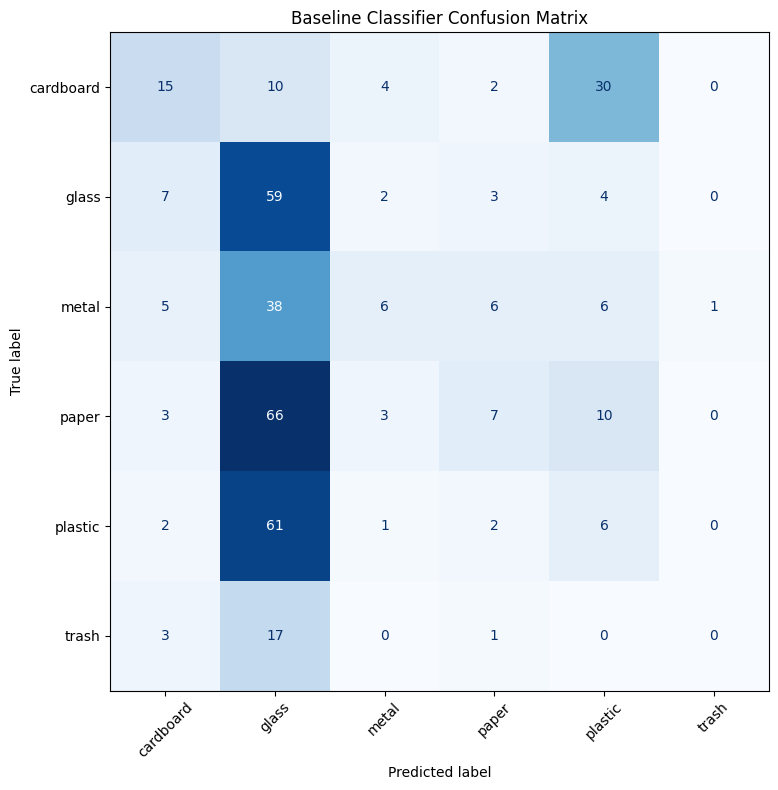

In [9]:
cm = confusion_matrix(y_test, y_pred_baseline, labels=CLASS_ORDER)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Baseline Classifier Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'baseline_confusion_matrix.png'), dpi=150)
plt.show()

In [10]:
report = classification_report(y_test, y_pred_baseline, labels=CLASS_ORDER, target_names=CLASS_ORDER)
with open(os.path.join('..', 'results', 'baseline_classification_report.txt'), 'w') as f:
    f.write(report)

with open(os.path.join('..', 'results', 'baseline_accuracy.txt'), 'w') as f:
    f.write(f"Baseline Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

np.save(os.path.join('..', 'results', 'baseline_confusion_matrix.npy'), cm)

print("All results saved successfully")

All results saved successfully
